In [1]:
from scipy.integrate import solve_ivp
import ionerdss as ion
import numpy as np
import matplotlib.pyplot as plt
import subprocess

ioNERDSS version 1.1.0 loaded.


The simulaiton took 4mins 28s on macbook m3 pro.

In [2]:
! ../../bin/nerdss -f parms.inp > OUTPUT 

### kb = 1E3 s^-1

In [3]:
# in NERDSS parm.inp file, these are given for
# A(c) + A(q) <-> A(c!1).A(q!1)
onRate3Dka = 20   # nm^3 / us
offRatekb = 1000 # s^-1
sigma = 0.729108    # nm

# convert to us^-1
offRatekb /= 1e6

# translational diffusion const from A.mol
Dt = 10.0 # um^2 / s == nm^2 / us

k1on: 11.905040975690374 (uM-1s-1)
k1off: 0.0009015965114424264
k2on: 11.526943814440996 (uM-1s-1)
k2off: 0.0008729623318318889
Equilibrium Trimer: 1908.9209805936987
Equilibrium Trimer from sim: 1567.8121878121879+-40.473331969433694
simulation error: 17.8692%


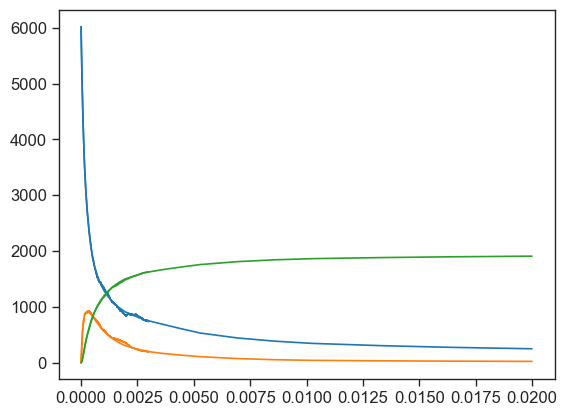

In [4]:
# for a system
#     A + A  <--> AA    k1on, k1off
#     AA + A <--> AAA   k2on, k2off
# in nerdss, there is one ka for the A+A binding, but
# the diffusion constant of AA is smaller than A, so
# the equivalent macro rate is not the same between
# the two reactions. We want ODE solutions that
# reflect this difference in kinetics. The difference
# should only be apparent when the association rate
# is high

# gives kon from ka
def equiv_macro_on(ka,sigma,D):
    return 1.0/((1.0/ka) + (1.0/(4.0*np.pi*sigma*D)) )

# gives ka from kon
def equiv_micro_on(kon,sigma,D):
    1.0/((1.0/kon) - (1.0/(4.0*np.pi*sigma*D)) )

# ODE system for above rxns
def rxn_sys(t,y,k):
    k1on,k1off,k2on,k2off,kclose,kopen = k
    A,AA,AAA,AAAc = y

    dA    = -2*k1on*A*A + 2*k1off*AA - 2*k2on*AA*A + 2*k2off*AAA
    dAA   = k1on*A*A - k1off*AA - 2*k2on*AA*A + 2*k2off*AAA
    dAAA  = 2*k2on*AA*A - 2*k2off*AAA - kclose*AAA + 3*kopen*AAAc
    dAAAc = kclose*AAA - 3*kopen*AAAc
    
    return np.array([dA,dAA,dAAA,dAAAc])


# from these microscopic NERDSS parameters,
# we get the following macro rates for
# the first reaction (A + A <--> AA)
k1on  = equiv_macro_on(onRate3Dka,sigma,2*Dt)
k1off = k1on*offRatekb/onRate3Dka
print(f"k1on: {k1on*0.66022} (uM-1s-1)")
print(f"k1off: {k1off}")

# for AA + A <--> AAA,
# D = Dt + Dt/2, since Dt for AA is Dt/2 of the monomer
k2on = equiv_macro_on(onRate3Dka,sigma,1.5*Dt)
k2off = k2on*offRatekb/onRate3Dka
print(f"k2on: {k2on*0.66022} (uM-1s-1)")
print(f"k2off: {k2off}")

 # loop coop factor of 1.0
kclose = onRate3Dka * 0.6022 * 1.0
kopen  = offRatekb

V = 5E7 # nm^3
init_conc_A = 6022 / V # num / nm^3

tfinal = 0.02E6 # us

res = solve_ivp(
    rxn_sys,
    [0.0,tfinal],
    y0=[init_conc_A,0.0,0.0,0.0],
    args=((k1on,k1off,k2on,k2off,kclose,kopen),),
    method='LSODA'
)

# time in sec on plot, so divide by 1e6
plt.plot(res.t/(1e6),res.y[0]*V)
plt.plot(res.t/(1e6),res.y[1]*V)
plt.plot(res.t/(1e6),(res.y[2]+res.y[3])*V)
equilibrium_trimer = (res.y[2]+res.y[3])[-1]*V
print(f"Equilibrium Trimer: {equilibrium_trimer}")

##################
# Now, load the NERDSS data

filename = "DATA/histogram_complexes_time.dat"

multi_species = ion.MultiHistogram(FileName=filename,FileNum=1,InitialTime=0.0,FinalTime=tfinal,SpeciesList=["A"])

data = multi_species.hist_to_df(SaveCsv = False)

times = data['Time(s):'].to_numpy()

Anums   = data['A: 1.  '].to_numpy()
AAnums  = data['A: 2.  '].to_numpy()
AAAnums = data['A: 3.  '].to_numpy()

statistic_start_index = int(2/3*len(AAAnums))
equilibrium_trimer_sim = AAAnums[statistic_start_index:]
mean_trimer_sim = np.mean(equilibrium_trimer_sim)
std_trimer_sim = np.std(equilibrium_trimer_sim)
print(f"Equilibrium Trimer from sim: {mean_trimer_sim}+-{std_trimer_sim}")
error_sim = (mean_trimer_sim - equilibrium_trimer) / equilibrium_trimer * 100 #%
error_sim = np.abs(error_sim)
print(f"simulation error: {error_sim:.4f}%")

plt.plot(times,Anums,color="C0")
plt.plot(times,AAnums,color="C1")
plt.plot(times,AAAnums,color="C2")

plt.show()